C:\Users\Yashoda\AppData\Local\Temp\ipykernel_15140\4053595499.py:10: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data_files/data_files/diabetic_data.csv", na_values="?")


Weight column removed.
Remaining records: 100114
Scrape කිරීමට නියමිත කේත: ['428', '414', '786', '410', '486', '427', '491', '715', '682', '434', '780', '996', '276', '38', '250.8', '599', '584', 'V57', '250.6', '518']
428 Heart failure
414 Other forms of chronic ischemic heart disease
786 Symptoms involving respiratory system and other chest symptoms
410 Acute myocardial infarction
486 Pneumonia, organism unspecified
427 Cardiac dysrhythmias
491 Chronic bronchitis
715 Osteoarthrosis and allied disorders
682 Other cellulitis and abscess
434 Occlusion of cerebral arteries
780 General symptoms
996 Complications peculiar to certain specified procedures
276 Disorders of fluid, electrolyte, and acid-base balance
Description Not Found
250.8 Diabetes with other specified manifestations
599 Other disorders of urethra and urinary tract
584 Acute renal failure
V57 Care involving use of rehabilitation procedures
250.6 Diabetes with neurological manifestations
518 Other diseases of lung


C:\Users\Yashoda\AppData\Local\Temp\ipykernel_15140\4053595499.py:121: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='readmitted', order=['NO', '>30', '<30'], palette='magma')


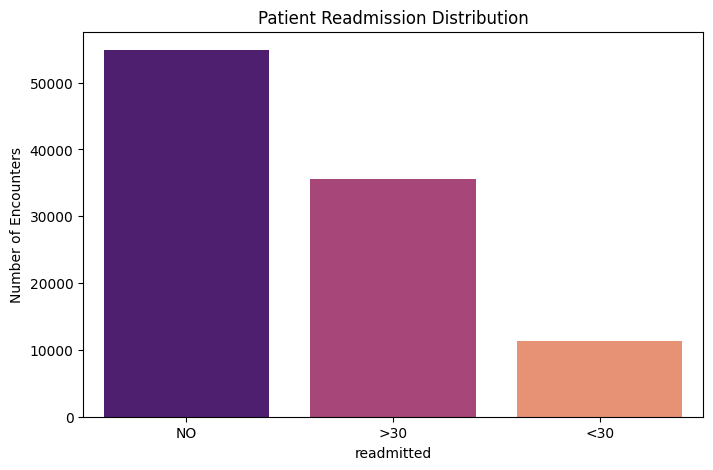

In [ ]:
import pandas as pd
import numpy as np
import requests
from bs4 import BeautifulSoup
import time
import matplotlib.pyplot as plt
import seaborn as sns

# 'data_files' folder එක ඇතුළේ ඇති බව සඳහන් කරන්න
df = pd.read_csv("data_files/data_files/diabetic_data.csv", na_values="?")

# නිවැරදිව load වී ඇත්දැයි බැලීමට (Null values ගණන පරීක්ෂා කරන්න)
# print(df.isnull().sum())

# get data
# df.head(10)
# df.info()

# # check missing values percentage
# df.isna().mean() * 100

# # remove weight column
# df.drop(columns=["weight"], inplace=True) 
# print("Weight column removed.")

# #  remove expired patients
# expired_ids = [11, 19, 20]
# df = df[~df["discharge_disposition_id"].isin(expired_ids)]
# print(f"Remaining records: {len(df)}")

# # remove duplicate rows
# df = df.drop_duplicates()

# # clean invalid gender values
# df["gender"] = df["gender"].replace("Unknown/Invalid", np.nan)



def cleanData(df):
    # check missing values percentage
    df.isna().mean() * 100

    # remove weight column
    df.drop(columns=["weight"], inplace=True) 
    print("Weight column removed.")

    #  remove expired patients
    expired_ids = [11, 19, 20]
    df = df[~df["discharge_disposition_id"].isin(expired_ids)]
    print(f"Remaining records: {len(df)}")

    # remove duplicate rows
    df = df.drop_duplicates()

    # clean invalid gender values
    df["gender"] = df["gender"].replace("Unknown/Invalid", np.nan)
    
    return df
    

df_cleaned = cleanData(df)

# categorical columns correct 
categorical_cols = ["race", "gender", "age", "readmitted"]

for col in categorical_cols:
    df[col] = df[col].astype("category")





## phaase 2: Scrape data from website   


# වැඩිපුරම ඇති රෝග විනිශ්චය කේත 20 ලබා ගැනීම
top_20_codes = df['diag_1'].value_counts().head(20).index.tolist()
print(f"Scrape කිරීමට නියමිත කේත: {top_20_codes}")    


# වෙබ් අඩවියෙන් විස්තර scrape කිරීමේ function එක
def scrape_icd9_descriptions(codes):
    descriptions = {}

    base_url = "http://icd9.chrisendres.com/index.php?srchtype=diseases&srchtext={code}&Submit=Search&action=search"

    for code in codes:
        url = base_url.format(code=code)

        response = requests.get(url)

        if response.status_code != 200:
            descriptions[code] = "Request Failed"
            continue

        soup = BeautifulSoup(response.text, "html.parser")

        result_cell = soup.find("div", class_="dlvl")


        if result_cell:
            result_text = result_cell.get_text(strip=True)
        else:
            result_text = "Description Not Found"

        descriptions[code] = result_text
        print(result_text)

        time.sleep(1)

    return descriptions

# Scrape කිරීම ආරම්භ කරන්න
scraped_data = scrape_icd9_descriptions(top_20_codes)


##phase 3: Save scraped data to CSV file


plt.figure(figsize=(8,5))
sns.countplot(data=df, x='readmitted', order=['NO', '>30', '<30'], palette='magma')
plt.title('Patient Readmission Distribution')
plt.ylabel('Number of Encounters')
plt.show()



# 2. Demographic Profiling

# 1. Age Distribution

plt.figure(figsize=(8,4))
# Define age order (as in dataset)
age_order = ['[0-10)','[10-20)','[20-30)','[30-40)','[40-50)','[50-60)',
             '[60-70)','[70-80)','[80-90)','[90-100)']
sns.countplot(data=df_cleaned, x='age', order=age_order, palette='viridis')
plt.title('Patient Age Distribution')
plt.xlabel('Age Group')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45)
plt.show()

# Optional insight
age_counts = df_cleaned['age'].value_counts().sort_index()
print("Age Distribution:\n", age_counts)





